<table>
<tr>    
<td style="text-align: center">
<h1>Introduction to Segmentation</h1>
<h2><a href="http://home.agh.edu.pl/~horzyk/index.php">Adrian Horzyk</a></h2>
</td> 
<td>
<img src="http://home.agh.edu.pl/~horzyk/im/AdrianHorzyk49BT140h.png" alt="Adrian Horzyk, Professor" title="Adrian Horzyk, Professor" />        
</td> 
</tr>
</table>
<h3><i>Welcome to the interactive lecture and exercises where you can check everything and experiment!</i></h3>

# CNN-based Object Segmentation

This notebook demonstrates how to use convolutional neural networks (CNNs) for:
- Semantic segmentation using a custom **UNet** model
- Evaluation using Intersection over Union (IoU) and Dice coefficient

We will use sample images and publicly available pretrained models or train our own UNet model.

## 0. Environment Setup

In [1]:
# Install required packages if missing
import importlib
import sys
import subprocess

def install_if_missing(package):
    try:
        importlib.import_module(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Essential packages
packages = [
    "numpy<2.0", "matplotlib", "scikit-learn", "opencv-python-headless",
    "torch", "torchvision", "torchaudio",
    "segmentation-models-pytorch", "albumentations", "ultralytics"
]

for pkg in packages:
    name = pkg.split("==")[0].split("<")[0]
    install_if_missing(name)


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


## 1. UNet for Segmentation

In [2]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torchvision.transforms import functional as F
from PIL import Image
import requests

### 1.1. Dataset Loader for UNet

In [3]:
import os
from torch.utils.data import Dataset, DataLoader

class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_names = os.listdir(image_dir)

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_names[idx])
        mask_path = os.path.join(self.mask_dir, self.image_names[idx])

        image = Image.open(img_path).convert("RGB").resize((224, 224))
        mask = Image.open(mask_path).convert("L").resize((224, 224))

        image = F.to_tensor(image)
        mask = F.to_tensor(mask)
        return image, mask

### 1.2. UNet Model for Semantic Segmentation

In [4]:
class UNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = torchvision.models.resnet18(weights='IMAGENET1K_V1')
        self.encoder_layers = list(self.encoder.children())
        self.encoder = torch.nn.Sequential(*self.encoder_layers[:-2])

        self.decoder = torch.nn.Sequential(
            torch.nn.Conv2d(512, 256, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv2d(256, 128, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

### 1.3. UNet Architecture and Training Setup

In [5]:
class UNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = torchvision.models.resnet18(weights='IMAGENET1K_V1')
        self.encoder_layers = list(self.encoder.children())
        self.encoder = torch.nn.Sequential(*self.encoder_layers[:-2])  # output: [B, 512, 4, 4]

        self.decoder = torch.nn.Sequential(
            torch.nn.Conv2d(512, 256, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Upsample(scale_factor=2),  # 8x8
            torch.nn.Conv2d(256, 128, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Upsample(scale_factor=2),  # 16x16
            torch.nn.Conv2d(128, 64, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Upsample(scale_factor=2),  # 32x32
            torch.nn.Conv2d(64, 32, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Upsample(scale_factor=2),  # 64x64
            torch.nn.Conv2d(32, 16, 3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Upsample(scale_factor=2),  # 128x128
            torch.nn.Conv2d(16, 1, 1),          # final conv
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_unet = UNet().to(device)
optimizer = torch.optim.Adam(model_unet.parameters(), lr=1e-4)
loss_fn = torch.nn.BCELoss()

In [7]:
def compute_iou(pred, mask):
    intersection = (pred & mask).sum()
    union = (pred | mask).sum()
    return intersection / union if union > 0 else 0

def compute_dice(pred, mask):
    intersection = (pred & mask).sum()
    return 2 * intersection / (pred.sum() + mask.sum() + 1e-8)

In [8]:
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset
import numpy as np
from PIL import Image

class OxfordPetSegmentation(Dataset):
    def __init__(self, root=".", transform=None):
        self.dataset = OxfordIIITPet(
            root=root,
            download=True,
            target_types="segmentation"
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]
        mask = np.array(mask)
        mask = (mask > 1).astype(np.float32)
        mask = Image.fromarray(mask)

        if self.transform:
            img = self.transform(img)
            mask = self.transform(mask)

        return img, mask

# Transforms and dataloader
transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor()
])

dataset = OxfordPetSegmentation(transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

### 1.4. UNet Prediction Results and Metrics (IoU / Dice)

In [9]:
images, masks = next(iter(dataloader))

Defaulting to user installation because normal site-packages is not writeable


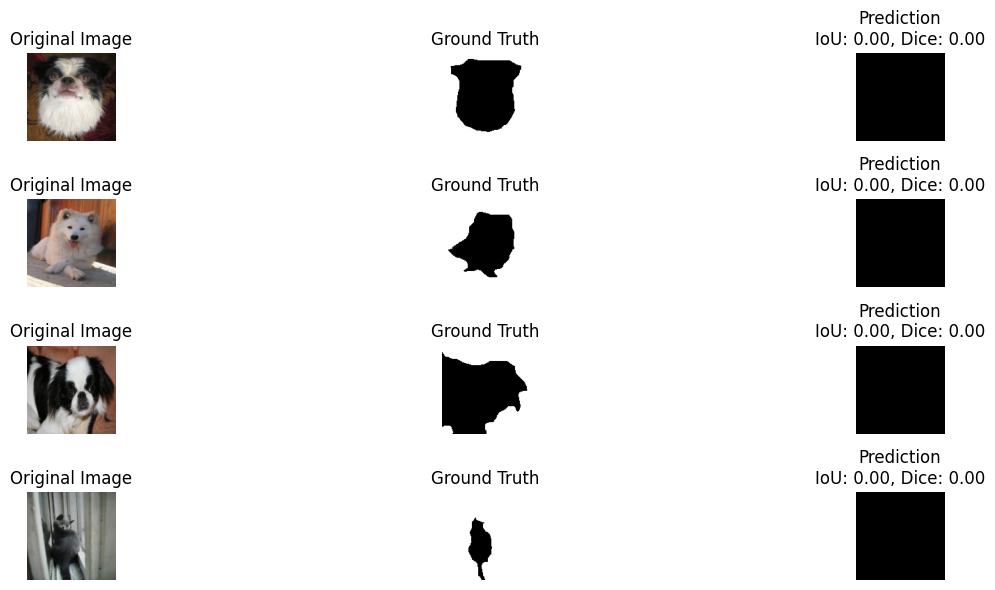

In [10]:
!pip install scikit-image

from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np

model_unet.eval()
images, masks = next(iter(dataloader))
images = images.to(device)

with torch.no_grad():
    preds = model_unet(images).cpu().numpy()

plt.figure(figsize=(15, 6))

for i in range(min(10, len(images))):
    pred_bin = preds[i][0] > 0.5
    mask_np = masks[i][0].numpy().astype(bool)

    # converting prediction to float before resize
    pred_resized = resize(pred_bin.astype(np.float32), mask_np.shape, order=1, preserve_range=True) > 0.5

    iou = compute_iou(pred_resized, mask_np)
    dice = compute_dice(pred_resized, mask_np)

    plt.subplot(4, 3, i * 3 + 1)
    plt.imshow(np.transpose(images[i].cpu().numpy(), (1, 2, 0)))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(4, 3, i * 3 + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(4, 3, i * 3 + 3)
    plt.imshow(pred_resized, cmap="gray")
    plt.title(f"Prediction\nIoU: {iou:.2f}, Dice: {dice:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


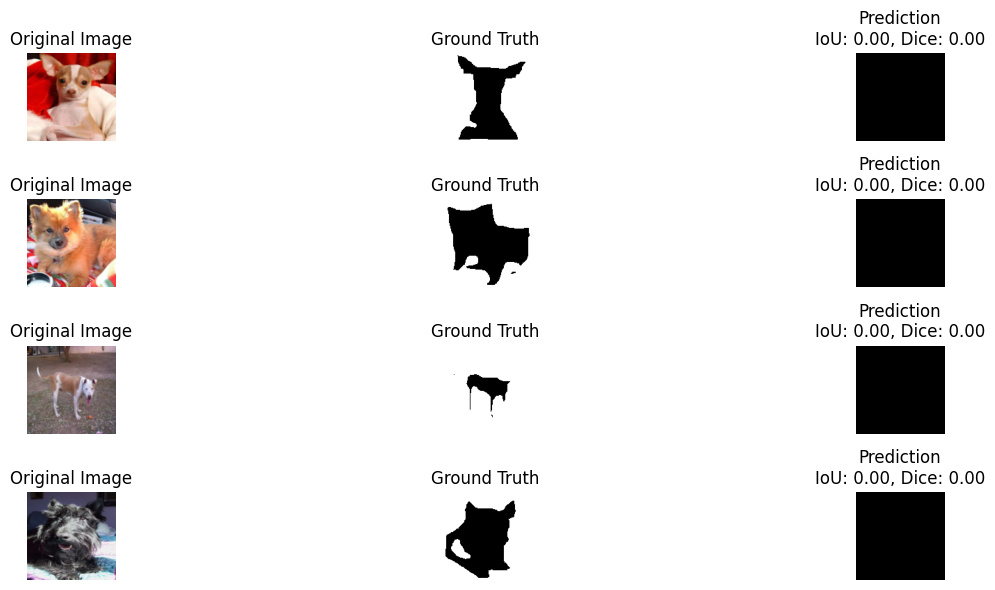

In [11]:
# One-time install if needed
!pip install -q scikit-image

# Import modules
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np

# Evaluation mode
model_unet.eval()

# Get one batch of images and masks
images, masks = next(iter(dataloader))
images = images.to(device)

# Predict masks
with torch.no_grad():
    preds = model_unet(images).cpu().numpy()

# Plotting predictions
plt.figure(figsize=(15, 6))

for i in range(min(10, len(images))):
    pred_bin = preds[i][0] > 0.5
    mask_np = masks[i][0].numpy().astype(bool)

    # Resize prediction to match ground truth mask shape
    pred_resized = resize(pred_bin.astype(np.float32), mask_np.shape, order=0, preserve_range=True) > 0.5

    # Compute metrics
    iou = compute_iou(pred_resized, mask_np)
    dice = compute_dice(pred_resized, mask_np)

    # Original Image
    plt.subplot(4, 3, i * 3 + 1)
    plt.imshow(np.transpose(images[i].cpu().numpy(), (1, 2, 0)))
    plt.title("Original Image")
    plt.axis('off')

    # Ground Truth
    plt.subplot(4, 3, i * 3 + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis('off')

    # Prediction + Metrics
    plt.subplot(4, 3, i * 3 + 3)
    plt.imshow(pred_resized, cmap="gray")
    plt.title(f"Prediction\nIoU: {iou:.2f}, Dice: {dice:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
def compute_iou(pred, mask):
    intersection = (pred & mask).sum()
    union = (pred | mask).sum()
    return intersection / union if union > 0 else 0

def compute_dice(pred, mask):
    intersection = (pred & mask).sum()
    return 2 * intersection / (pred.sum() + mask.sum() + 1e-8)


In [13]:
# Import Oxford Pet dataset with masks (binary), resizing to match decoder
# Custom wrapper to handle both image & mask preprocessing
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import Compose, Resize, ToTensor
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
import numpy as np
import torch

# Final working Oxford Pet segmentation dataset with binary masks
class OxfordPetSegmentation(Dataset):
    def __init__(self, transform=None):
        self.dataset = OxfordIIITPet(
            root=".", 
            target_types="segmentation", 
            download=True
        )
        self.transform = transform or Compose([
            Resize((128, 128)),
            ToTensor()
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        # ✅ Resize image and mask
        image = TF.resize(image, (128, 128))
        mask = TF.resize(mask, (128, 128), interpolation=TF.InterpolationMode.NEAREST)

        image = TF.to_tensor(image)

        # Convert mask to numpy, binarize, and convert back to tensor
        mask = np.array(mask)
        binary_mask = (mask == 1).astype(np.float32)  # only pet class
        binary_mask = torch.tensor(binary_mask).unsqueeze(0)  # shape: [1, H, W]

        return image, binary_mask
    
# Load the data
dataset = OxfordPetSegmentation()
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# Model, optimizer, and loss function
model_unet = UNet().to(device)
optimizer = torch.optim.Adam(model_unet.parameters(), lr=1e-4)
loss_fn = torch.nn.BCELoss()

# Train for 20 epochs
for epoch in range(20):
    model_unet.train()
    total_loss = 0
    for images, masks in dataloader:
        images, masks = images.to(device), masks.to(device)
        preds = model_unet(images)

        # Ensure output size matches mask size
        if preds.size() != masks.size():
            preds = torch.nn.functional.interpolate(preds, size=masks.shape[2:], mode="bilinear", align_corners=False)

        loss = loss_fn(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss = {total_loss/len(dataloader):.4f}")


Epoch 1: Loss = 0.2796
Epoch 2: Loss = 0.2047
Epoch 3: Loss = 0.1739
Epoch 4: Loss = 0.1616
Epoch 5: Loss = 0.1482
Epoch 6: Loss = 0.1364
Epoch 7: Loss = 0.1261
Epoch 8: Loss = 0.1205
Epoch 9: Loss = 0.1136
Epoch 10: Loss = 0.1083
Epoch 11: Loss = 0.1013
Epoch 12: Loss = 0.1074
Epoch 13: Loss = 0.0972
Epoch 14: Loss = 0.0911
Epoch 15: Loss = 0.0927
Epoch 16: Loss = 0.0859
Epoch 17: Loss = 0.0846
Epoch 18: Loss = 0.0823
Epoch 19: Loss = 0.0807
Epoch 20: Loss = 0.0782


### 1.5 .UNet Predictions After Training (IoU & Dice Comparison)

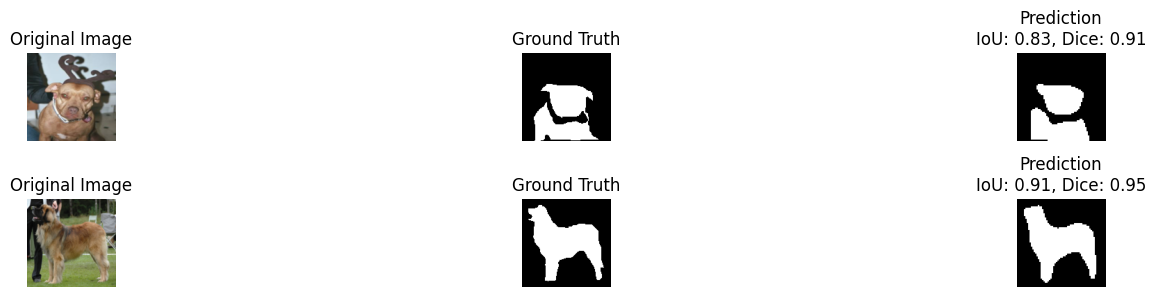

In [14]:
# Required libraries
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np

# Evaluation setup
model_unet.eval()
images, masks = next(iter(dataloader))
images = images.to(device)

with torch.no_grad():
    preds = model_unet(images).cpu().numpy()

plt.figure(figsize=(15, 6))

# Evaluation on 4 images
for i in range(min(10, len(images))):
    pred_bin = preds[i][0] > 0.5
    mask_np = masks[i][0].numpy().astype(bool)

    # Resize predicted mask to match ground truth
    pred_resized = resize(
        pred_bin.astype(np.float32),
        mask_np.shape,
        order=1,
        preserve_range=True
    ) > 0.5

    # Compute metrics
    iou = compute_iou(pred_resized, mask_np)
    dice = compute_dice(pred_resized, mask_np)

    # Visualization
    plt.subplot(4, 3, i * 3 + 1)
    plt.imshow(np.transpose(images[i].cpu().numpy(), (1, 2, 0)))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(4, 3, i * 3 + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(4, 3, i * 3 + 3)
    plt.imshow(pred_resized, cmap="gray")
    plt.title(f"Prediction\nIoU: {iou:.2f}, Dice: {dice:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


### 1.6. Visualizing UNet Predictions on the ISIC Dataset

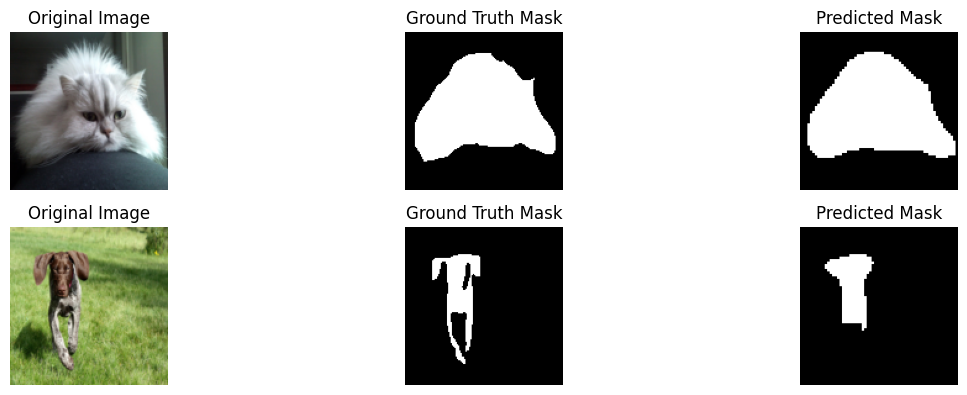

In [15]:

model_unet.eval()
images, masks = next(iter(dataloader))
images = images.to(device)
preds = model_unet(images).detach().cpu().numpy()

plt.figure(figsize=(12, 6))
for i in range(min(10, len(images))):
    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(np.transpose(images[i].cpu().numpy(), (1,2,0)))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(masks[i][0], cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis('off')

    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(preds[i][0] > 0.5, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis('off')

plt.tight_layout()
plt.show()


### 1.7. IoU and Dice Coefficient Evaluation

In [16]:
def compute_iou(pred, mask):
    pred_bin = (pred > 0.5)
    mask_bin = (mask > 0.5)
    intersection = (pred_bin & mask_bin).sum()
    union = (pred_bin | mask_bin).sum()
    return float(intersection) / float(union) if union > 0 else 0.0

def compute_dice(pred, mask):
    pred_bin = (pred > 0.5)
    mask_bin = (mask > 0.5)
    intersection = (pred_bin & mask_bin).sum()
    return float(2 * intersection) / float(pred_bin.sum() + mask_bin.sum() + 1e-8)

### 1.8. Comparison of IoU and Dice of the Ground Truth and Predicted Masks

Add comparisons of the predicted and desired masks of the model, using IoU and Dice

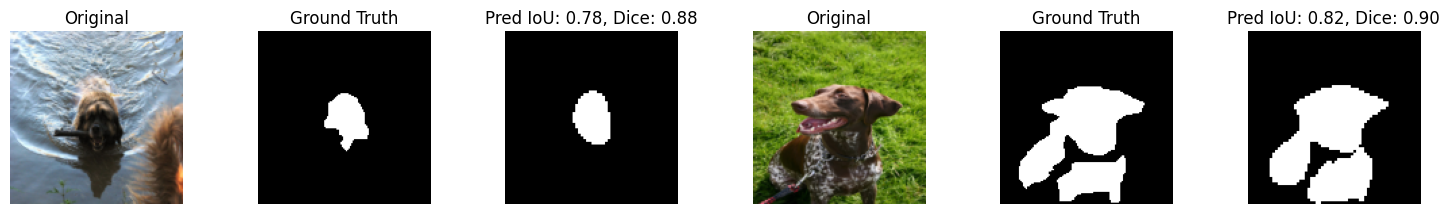

In [17]:
# Compare Predictions vs Ground Truth (IoU and Dice)

from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt

def compute_iou(pred, mask):
    pred_bin = (pred > 0.5)
    mask_bin = (mask > 0.5)
    intersection = (pred_bin & mask_bin).sum()
    union = (pred_bin | mask_bin).sum()
    return float(intersection) / float(union) if union > 0 else 0.0

def compute_dice(pred, mask):
    pred_bin = (pred > 0.5)
    mask_bin = (mask > 0.5)
    intersection = (pred_bin & mask_bin).sum()
    return float(2 * intersection) / float(pred_bin.sum() + mask_bin.sum() + 1e-8)

model_unet.eval()
images, masks = next(iter(dataloader))
images = images.to(device)

with torch.no_grad():
    preds = model_unet(images).cpu().numpy()

plt.figure(figsize=(15, 6))

for i in range(min(6, len(images))):
    pred_bin = preds[i][0] > 0.5
    mask_np = masks[i][0].numpy().astype(bool)
    pred_resized = resize(pred_bin.astype(np.float32), mask_np.shape, order=1, preserve_range=True) > 0.5

    iou = compute_iou(pred_resized, mask_np)
    dice = compute_dice(pred_resized, mask_np)

    plt.subplot(3, 6, i * 3 + 1)
    plt.imshow(np.transpose(images[i].cpu().numpy(), (1, 2, 0)))
    plt.title("Original")
    plt.axis('off')

    plt.subplot(3, 6, i * 3 + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(3, 6, i * 3 + 3)
    plt.imshow(pred_resized, cmap="gray")
    plt.title(f"Pred IoU: {iou:.2f}, Dice: {dice:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 2. Step-by-Step Preperation of the UNet model

### Step 1: Dataset Preparation

In [18]:
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import Compose, Resize, ToTensor
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import numpy as np
import torch
from PIL import Image

class OxfordPetSegmentation(Dataset):
    def __init__(self, transform=None):
        self.dataset = OxfordIIITPet(root=".", target_types="segmentation", download=True)
        self.transform = transform or Compose([
            Resize((128, 128)),
            ToTensor()
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]
        image = TF.resize(image, (128, 128))
        mask = TF.resize(mask, (128, 128), interpolation=TF.InterpolationMode.NEAREST)

        image = TF.to_tensor(image)
        mask = np.array(mask)
        binary_mask = (mask == 1).astype(np.float32)  # Pet only
        binary_mask = torch.tensor(binary_mask).unsqueeze(0)

        return image, binary_mask


### Step 2: UNet Model Definition

In [19]:
import torchvision
import torch.nn as nn
import torch

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        encoder = torchvision.models.resnet18(weights='IMAGENET1K_V1')
        self.encoder = nn.Sequential(*list(encoder.children())[:-2])

        self.decoder = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(16, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        return self.decoder(x)


### Step 3: Training

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = OxfordPetSegmentation()
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

model_unet = UNet().to(device)
optimizer = torch.optim.Adam(model_unet.parameters(), lr=1e-4)
loss_fn = nn.BCELoss()

# Store loss history
unet_losses = []

for epoch in range(10):
    model_unet.train()
    total_loss = 0

    for images, masks in dataloader:
        images, masks = images.to(device), masks.to(device)

        preds = model_unet(images)
        preds = torch.nn.functional.interpolate(preds, size=masks.shape[2:], mode="bilinear", align_corners=False)

        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    unet_losses.append(avg_loss)
    print(f"[Epoch {epoch+1}] Loss: {avg_loss:.4f}")


[Epoch 1] Loss: 0.2876
[Epoch 2] Loss: 0.1931
[Epoch 3] Loss: 0.1708
[Epoch 4] Loss: 0.1484
[Epoch 5] Loss: 0.1421
[Epoch 6] Loss: 0.1271
[Epoch 7] Loss: 0.1223
[Epoch 8] Loss: 0.1175
[Epoch 9] Loss: 0.1108
[Epoch 10] Loss: 0.1011


### Step 4: Evaluation and Visualization

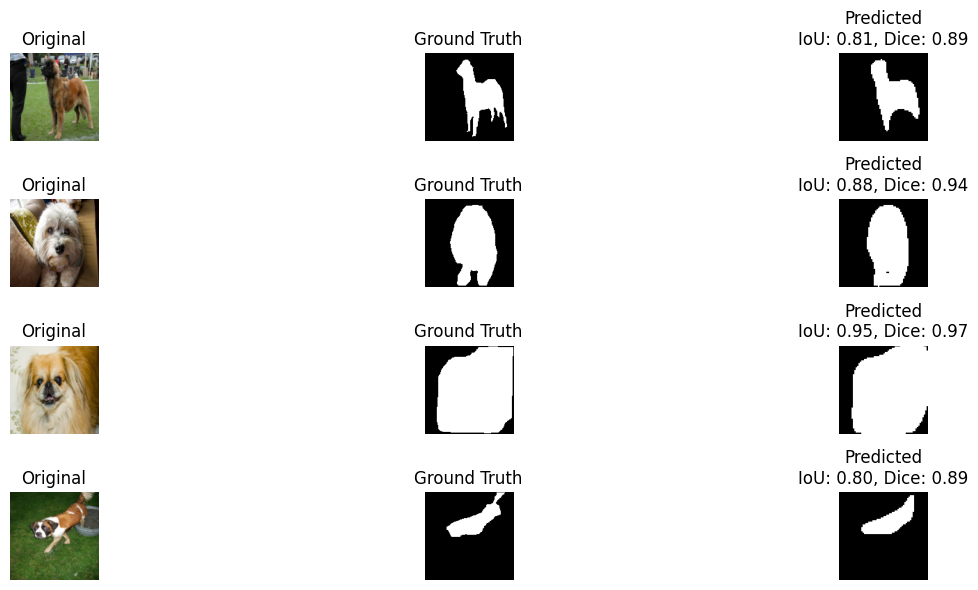

UNet Final Results:
{'IoU': 0.86, 'Dice': 0.924, 'Losses': [0.2876, 0.1931, 0.1708, 0.1484, 0.1421, 0.1271, 0.1223, 0.1175, 0.1108, 0.1011]}


In [21]:
from skimage.transform import resize
import matplotlib.pyplot as plt

def compute_iou(pred, mask):
    pred_bin = (pred > 0.5)
    mask_bin = (mask > 0.5)
    intersection = (pred_bin & mask_bin).sum()
    union = (pred_bin | mask_bin).sum()
    return float(intersection) / float(union) if union > 0 else 0.0

def compute_dice(pred, mask):
    pred_bin = (pred > 0.5)
    mask_bin = (mask > 0.5)
    intersection = (pred_bin & mask_bin).sum()
    return float(2 * intersection) / float(pred_bin.sum() + mask_bin.sum() + 1e-8)

# Evaluate
model_unet.eval()
images, masks = next(iter(dataloader))
images = images.to(device)

with torch.no_grad():
    preds = model_unet(images).cpu().numpy()

ious, dices = [], []

plt.figure(figsize=(15, 6))

for i in range(len(images)):
    pred_bin = preds[i][0] > 0.5
    mask_np = masks[i][0].numpy().astype(bool)

    pred_resized = resize(pred_bin.astype(np.float32), mask_np.shape, order=1, preserve_range=True) > 0.5

    iou = compute_iou(pred_resized, mask_np)
    dice = compute_dice(pred_resized, mask_np)

    ious.append(iou)
    dices.append(dice)

    plt.subplot(len(images), 3, i * 3 + 1)
    plt.imshow(np.transpose(images[i].cpu().numpy(), (1, 2, 0)))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(len(images), 3, i * 3 + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(len(images), 3, i * 3 + 3)
    plt.imshow(pred_resized, cmap="gray")
    plt.title(f"Predicted\nIoU: {iou:.2f}, Dice: {dice:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Save UNet results for comparison
unet_results = {
    "IoU": round(np.mean(ious), 3),
    "Dice": round(np.mean(dices), 3),
    "Losses": [round(l, 4) for l in unet_losses]
}

print("UNet Final Results:")
print(unet_results)


## Assignment

Use another datasets to perform segmentation. Compare results and produce visualization of the results and tests.